# Online Streaming Training with Catastrophic Forgetting Mitigation

| Strategy | Buffer Size | Replay Weight | Replay Batch |
|----------|------------|---------------|-------------|
| **Naive** (no CL) | - | - | - |
| **ER Scaled** | 50,000 | 0.7 | 10,000 |
| **ER Aggressive** | 100,000 | 1.0 | 20,000 |

**Training**: 20 temporal windows x 100 epochs per window

In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# Data path: /kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv


/kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv


In [11]:
"""
Online Streaming Training with Continual Learning Strategies
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import pyarrow.csv as pv
from torcheval.metrics import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import time
import os
import json

class SpatioTemporalDataset(Dataset):
    """
    PyTorch Dataset for spatio-temporal data with min-max normalization.
    Loads CSV data and applies min-max scaling to [0, 1] range.
    """
    def __init__(self, filepath):
        print(f'Loading dataset from {filepath}')
        read_options = pv.ReadOptions(
            column_names=['x', 'y', 'z', 't', 'Vx', 'Vy', 'Pressure', 'TKE']
        )
        table = pv.read_csv(filepath, read_options=read_options)
        data = table.to_pandas().values

        self.inputs = data[:, :4].astype(np.float32)
        self.targets = data[:, 4:].astype(np.float32)

        print('Applying min-max normalization to [0, 1] range')
        self.input_min = self.inputs.min(axis=0)
        self.input_max = self.inputs.max(axis=0)
        self.input_range = self.input_max - self.input_min
        self.input_range[self.input_range == 0] = 1.0
        self.inputs = (self.inputs - self.input_min) / self.input_range

        self.target_min = self.targets.min(axis=0)
        self.target_max = self.targets.max(axis=0)
        self.target_range = self.target_max - self.target_min
        self.target_range[self.target_range == 0] = 1.0
        self.targets = (self.targets - self.target_min) / self.target_range

        print(f'Dataset loaded: {len(self):,} samples')
        print(f'Input shape: {self.inputs.shape}, Target shape: {self.targets.shape}')

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.from_numpy(self.inputs[idx]), torch.from_numpy(self.targets[idx])

    def denormalize_inputs(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.cpu().numpy()
        return normalized * self.input_range + self.input_min

    def denormalize_targets(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.cpu().numpy()
        return normalized * self.target_range + self.target_min


class BaseCompressor(nn.Module):
    """Base model: 4 -> 64 -> 64 -> 32 -> 4 (6,692 parameters)"""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 4)
        )
    def forward(self, x):
        return self.network(x)


class MediumCompressor(nn.Module):
    """Medium model: 4 -> 96 -> 96 -> 48 -> 4 (14,644 parameters)"""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 96), nn.ReLU(),
            nn.Linear(96, 96), nn.ReLU(),
            nn.Linear(96, 48), nn.ReLU(),
            nn.Linear(48, 4)
        )
    def forward(self, x):
        return self.network(x)


class LargeCompressor(nn.Module):
    """Large model: 4 -> 128 -> 128 -> 64 -> 4 (25,668 parameters)"""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 4)
        )
    def forward(self, x):
        return self.network(x)


def compute_psnr_ssim(predictions, targets, device):
    """Compute PSNR and SSIM for regression data.

    Handles large tensors by computing on CPU if needed, only moving
    to device for the metric computation itself.
    """
    # Keep on CPU if tensors are very large to avoid GPU OOM
    n_samples = predictions.shape[0]
    use_cpu = n_samples > 1_000_000

    if use_cpu:
        metric_device = torch.device('cpu')
        predictions = predictions.cpu()
        targets = targets.cpu()
    else:
        metric_device = device
        predictions = predictions.to(device)
        targets = targets.to(device)

    psnr_metric = PeakSignalNoiseRatio().to(metric_device)
    psnr_metric.update(predictions, targets)
    psnr = psnr_metric.compute().item()

    pred_ssim = predictions.view(-1, 1, 1, predictions.shape[1]).permute(1, 2, 0, 3)
    target_ssim = targets.view(-1, 1, 1, targets.shape[1]).permute(1, 2, 0, 3)

    ssim_metric = StructuralSimilarityIndexMeasure(
        gaussian_kernel=False, kernel_size=1
    ).to(metric_device)
    ssim_metric.update(pred_ssim, target_ssim)
    ssim = ssim_metric.compute().item()

    return psnr, ssim


def compute_relative_error(predictions, targets):
    """Compute relative L2 norm error as percentage."""
    error_norm = torch.norm(predictions - targets)
    target_norm = torch.norm(targets)
    return (error_norm / target_norm * 100).item()


print('Dataset, models, and metrics defined.')

class ReplayBuffer:
    """
    Fixed-size replay buffer with reservoir sampling.
    Ensures uniform temporal coverage across all observed windows.
    Optionally stores model predictions (logits) for DER++.
    """

    def __init__(self, max_size=10000, store_logits=False):
        self.max_size = max_size
        self.store_logits = store_logits
        self.inputs = None
        self.targets = None
        self.logits = None
        self.count = 0
        self.current_size = 0

    def add_window(self, inputs, targets, logits=None):
        """Add samples using reservoir sampling."""
        inputs_cpu = inputs.detach().cpu()
        targets_cpu = targets.detach().cpu()
        logits_cpu = logits.detach().cpu() if logits is not None else None
        n_samples = inputs_cpu.shape[0]

        if self.inputs is None:
            n_init = min(n_samples, self.max_size)
            self.inputs = inputs_cpu[:n_init].clone()
            self.targets = targets_cpu[:n_init].clone()
            if self.store_logits and logits_cpu is not None:
                self.logits = logits_cpu[:n_init].clone()
            self.current_size = n_init
            self.count = n_init
            start_idx = n_init
        else:
            start_idx = 0

        for i in range(start_idx, n_samples):
            self.count += 1
            if self.current_size < self.max_size:
                self.inputs = torch.cat([self.inputs, inputs_cpu[i:i+1]], dim=0)
                self.targets = torch.cat([self.targets, targets_cpu[i:i+1]], dim=0)
                if self.store_logits and logits_cpu is not None:
                    self.logits = torch.cat([self.logits, logits_cpu[i:i+1]], dim=0)
                self.current_size += 1
            else:
                j = np.random.randint(0, self.count)
                if j < self.max_size:
                    self.inputs[j] = inputs_cpu[i]
                    self.targets[j] = targets_cpu[i]
                    if self.store_logits and logits_cpu is not None:
                        self.logits[j] = logits_cpu[i]

    def add_window_batch(self, inputs, targets, logits=None, n_samples=None):
        """Efficiently add a random subset of window samples to the buffer."""
        window_size = inputs.shape[0]
        if n_samples is None:
            n_samples = min(window_size, self.max_size // 2)
        indices = torch.randperm(window_size)[:n_samples]
        sub_inputs = inputs[indices]
        sub_targets = targets[indices]
        sub_logits = logits[indices] if logits is not None else None
        self.add_window(sub_inputs, sub_targets, sub_logits)

    def sample(self, batch_size, device=None):
        """Sample a random batch from the buffer."""
        if self.current_size == 0:
            return None
        actual_batch = min(batch_size, self.current_size)
        indices = torch.randperm(self.current_size)[:actual_batch]
        batch_inputs = self.inputs[indices]
        batch_targets = self.targets[indices]
        if device is not None:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
        if self.store_logits and self.logits is not None:
            batch_logits = self.logits[indices]
            if device is not None:
                batch_logits = batch_logits.to(device)
            return batch_inputs, batch_targets, batch_logits
        return batch_inputs, batch_targets

    def __len__(self):
        return self.current_size


print('ReplayBuffer defined.')
class NaiveStrategy:
    """No forgetting mitigation."""
    name = "naive"
    def get_config(self): return {"strategy": self.name}
    def before_window(self, model, window_idx, window_inputs, window_targets, device): pass
    def compute_loss(self, model, crit, out, targets, window_inputs, device):
        return crit(out, targets)
    def after_window(self, model, window_idx, window_inputs, window_targets, device): pass


class ERStrategy:
    """Experience Replay with configurable buffer and replay weight."""
    def __init__(self, name, buffer_size, replay_weight, replay_batch_size):
        self.name = name
        self.buffer = ReplayBuffer(max_size=buffer_size)
        self.replay_weight = replay_weight
        self.replay_batch_size = replay_batch_size

    def before_window(self, model, window_idx, window_inputs, window_targets, device): pass

    def compute_loss(self, model, crit, out, targets, window_inputs, device):
        current_loss = crit(out, targets)
        if len(self.buffer) == 0:
            return current_loss
        r_inp, r_tgt = self.buffer.sample(self.replay_batch_size, device=device)
        r_out = model(r_inp)
        replay_loss = crit(r_out, r_tgt)
        return current_loss + self.replay_weight * replay_loss

    def after_window(self, model, window_idx, window_inputs, window_targets, device):
        self.buffer.add_window_batch(window_inputs, window_targets)
    def get_config(self):
        return {"strategy": self.name, "buffer_size": self.buffer.max_size, "replay_weight": self.replay_weight}

def train_online_cl(model, dataset, device, epochs_per_window, model_name,
                    output_dir, strategy, num_windows=20):
    """
    Train neural network using online streaming with a continual learning strategy.
    Data is divided into temporal windows and processed sequentially.
    """
    os.makedirs(output_dir, exist_ok=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    metrics = {
        'window': [], 'loss': [], 'psnr': [], 'ssim': [],
        'relative_error': [], 'time_per_window': []
    }

    total_params = sum(p.numel() for p in model.parameters())
    print(f'\n[Training Configuration]')
    print(f'  Strategy     : {strategy.name}')
    print(f'  Model        : {model_name} ({total_params:,} parameters, {total_params * 4 / 1024:.1f} KB)')
    print(f'  Windows      : {num_windows}')
    print(f'  Epochs/window: {epochs_per_window}')
    print(f'  Device       : {device}')

    coords_denorm = dataset.denormalize_inputs(dataset.inputs)
    unique_times = np.unique(coords_denorm[:, 3])
    times_per_window = len(unique_times) // num_windows
    print(f'  Timesteps    : {len(unique_times)} total, {times_per_window} per window\n')

    total_start = time.time()

    for window_idx in range(num_windows):
        window_start = time.time()

        start_idx = window_idx * times_per_window
        end_idx = start_idx + times_per_window if window_idx < num_windows - 1 else len(unique_times)
        window_times = unique_times[start_idx:end_idx]

        time_mask = np.isin(coords_denorm[:, 3], window_times)
        window_inputs = torch.from_numpy(dataset.inputs[time_mask]).to(device)
        window_targets = torch.from_numpy(dataset.targets[time_mask]).to(device)

        strategy.before_window(model, window_idx, window_inputs, window_targets, device)

        model.train()
        for epoch in range(epochs_per_window):
            optimizer.zero_grad()
            outputs = model(window_inputs)
            loss = strategy.compute_loss(
                model, criterion, outputs, targets=window_targets,
                window_inputs=window_inputs, device=device
            )
            loss.backward()
            optimizer.step()

        strategy.after_window(model, window_idx, window_inputs, window_targets, device)

        model.eval()
        with torch.no_grad():
            predictions = model(window_inputs)

        loss_val = criterion(predictions, window_targets).item()
        psnr, ssim = compute_psnr_ssim(predictions, window_targets, device)
        rel_error = compute_relative_error(predictions, window_targets)
        window_time = time.time() - window_start

        metrics['window'].append(window_idx + 1)
        metrics['loss'].append(loss_val)
        metrics['psnr'].append(psnr)
        metrics['ssim'].append(ssim)
        metrics['relative_error'].append(rel_error)
        metrics['time_per_window'].append(window_time)

        print(f'  Window {window_idx+1:3d}/{num_windows}: '
              f'PSNR={psnr:.2f} dB, SSIM={ssim:.4f}, '
              f'RE={rel_error:.2f}%, Time={window_time:.2f}s')

    total_time = time.time() - total_start

    final_model_path = os.path.join(output_dir, f'{model_name}_final.pth')
    torch.save(model.state_dict(), final_model_path)

    norm_params = {
        'input_min': dataset.input_min.tolist(),
        'input_max': dataset.input_max.tolist(),
        'input_range': dataset.input_range.tolist(),
        'target_min': dataset.target_min.tolist(),
        'target_max': dataset.target_max.tolist(),
        'target_range': dataset.target_range.tolist()
    }
    with open(os.path.join(output_dir, f'{model_name}_normalization.json'), 'w') as f:
        json.dump(norm_params, f, indent=2)

    summary = {
        'model_name': model_name, 'strategy': strategy.get_config(),
        'total_windows': num_windows, 'epochs_per_window': epochs_per_window,
        'total_epochs': num_windows * epochs_per_window,
        'final_loss': metrics['loss'][-1], 'final_psnr': metrics['psnr'][-1],
        'final_ssim': metrics['ssim'][-1],
        'final_relative_error': metrics['relative_error'][-1],
        'total_training_time': total_time,
        'avg_time_per_window': total_time / num_windows
    }
    with open(os.path.join(output_dir, 'online_training_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)

    df = pd.DataFrame(metrics)
    csv_path = os.path.join(output_dir, f'{model_name}_{strategy.name}_metrics.csv')
    df.to_csv(csv_path, index=False)

    print(f'\n[Training Complete] {strategy.name}')
    print(f'  Final PSNR   : {metrics["psnr"][-1]:.2f} dB')
    print(f'  Final SSIM   : {metrics["ssim"][-1]:.4f}')
    print(f'  Final RE     : {metrics["relative_error"][-1]:.2f}%')
    print(f'  Total time   : {total_time:.2f}s')
    print(f'  Model saved  : {final_model_path}\n')


    # Full-dataset evaluation
    print(f'\n[Full-Dataset Evaluation]')
    model.eval()
    all_inputs = torch.from_numpy(dataset.inputs)
    all_targets = torch.from_numpy(dataset.targets)
    preds_list = []
    with torch.no_grad():
        for start in range(0, len(all_inputs), 500000):
            end = min(start + 500000, len(all_inputs))
            preds_list.append(model(all_inputs[start:end].to(device)).cpu())
    all_preds = torch.cat(preds_list, dim=0)
    full_psnr, full_ssim = compute_psnr_ssim(all_preds, all_targets, device)
    full_re = compute_relative_error(all_preds, all_targets)
    print(f'  PSNR: {full_psnr:.2f} dB | SSIM: {full_ssim:.4f} | RE: {full_re:.2f}%')

    eval_results = {
        'model': model_name, 'strategy': strategy.name,
        'parameters': total_params,
        'psnr_db': float(full_psnr), 'ssim': float(full_ssim),
        'relative_error_pct': float(full_re),
        'training_time_s': total_time
    }
    eval_path = os.path.join(output_dir, 'evaluation_metrics.json')
    with open(eval_path, 'w') as f:
        json.dump(eval_results, f, indent=2)

    return metrics, eval_results, all_preds


def evaluate_full_dataset(model, dataset, device, model_name=None, batch_size=500000):
    """
    Evaluate model on the entire dataset to reveal catastrophic forgetting.
    Tests reconstruction quality across ALL timesteps.

    Uses batched inference to avoid GPU OOM on large models — processing
    7.9M samples at once requires ~10 GB of intermediate activations for
    the large model, which can silently corrupt results.
    """
    model.eval()

    # Free GPU memory before evaluation
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    all_inputs = torch.from_numpy(dataset.inputs)
    all_targets = torch.from_numpy(dataset.targets)
    n_samples = all_inputs.shape[0]

    # Batched inference to avoid GPU OOM
    predictions_list = []
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            batch_preds = model(all_inputs[start:end].to(device)).cpu()
            predictions_list.append(batch_preds)

    all_predictions = torch.cat(predictions_list, dim=0)

    # Compute metrics on CPU to avoid memory pressure, then move for PSNR/SSIM
    criterion = nn.MSELoss()
    loss = criterion(all_predictions, all_targets).item()
    rel_error = compute_relative_error(all_predictions, all_targets)

    # PSNR and SSIM need to be on device — move in batches if needed
    psnr, ssim = compute_psnr_ssim(all_predictions, all_targets, device)

    label = model_name if model_name else 'model'
    print(f'[Full Dataset Evaluation] {label}')
    print(f'  PSNR : {psnr:.2f} dB | SSIM : {ssim:.4f} | RE : {rel_error:.2f}%')

    return {'loss': loss, 'psnr_db': psnr, 'ssim': ssim, 'relative_error_pct': rel_error}


print('Training loop and evaluation functions defined.')

from matplotlib.gridspec import GridSpec


def visualize_flow_field(model, dataset, device, timestep_idx=None,
                         title='Flow Field Reconstruction', save_path=None):
    """
    Visualize original vs predicted flow fields around the cylinder.

    Generates a 4-row grid: rows are field variables (Vx, Vy, Pressure, TKE).
    Columns: Original, Predicted, shared colorbar, Absolute Error, error colorbar.
    Original and Predicted share one colorbar; Error has its own.
    """
    model.eval()
    coords_phys = dataset.denormalize_inputs(dataset.inputs)
    unique_times = np.unique(coords_phys[:, 3])

    if timestep_idx is None:
        timestep_idx = len(unique_times) // 2
    t_val = unique_times[timestep_idx]

    t_mask = np.abs(coords_phys[:, 3] - t_val) < 1e-8
    z_vals = np.unique(np.round(coords_phys[t_mask, 2], 8))
    if len(z_vals) > 1:
        z_mid = z_vals[len(z_vals) // 2]
        mask = t_mask & (np.abs(coords_phys[:, 2] - z_mid) < 1e-8)
    else:
        mask = t_mask

    x_phys = coords_phys[mask, 0]
    y_phys = coords_phys[mask, 1]
    targets = dataset.targets[mask]

    inputs_t = torch.from_numpy(dataset.inputs[mask]).to(device)
    with torch.no_grad():
        preds = model(inputs_t).cpu().numpy()
    preds = np.clip(preds, 0, 1)
    abs_err = np.abs(targets - preds)

    field_names = ['Vx', 'Vy', 'Pressure', 'TKE']

    # GridSpec: Original | Predicted | cbar | Error | cbar
    fig = plt.figure(figsize=(20, 20))
    gs = GridSpec(4, 5, figure=fig,
                  width_ratios=[1, 1, 0.05, 1, 0.05],
                  wspace=0.35, hspace=0.25)

    for row in range(4):
        original = targets[:, row]
        predicted = preds[:, row]
        error = abs_err[:, row]

        # Original
        ax0 = fig.add_subplot(gs[row, 0])
        ax0.scatter(x_phys, y_phys, c=original, cmap='jet',
                    s=0.5, alpha=0.8, vmin=0, vmax=1)
        ax0.set_title(f'Original: {field_names[row]}')
        ax0.set_aspect('equal')
        ax0.grid(True, alpha=0.3)

        # Predicted
        ax1 = fig.add_subplot(gs[row, 1])
        sc2 = ax1.scatter(x_phys, y_phys, c=predicted, cmap='jet',
                          s=0.5, alpha=0.8, vmin=0, vmax=1)
        ax1.set_title(f'Predicted: {field_names[row]}')
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)

        # Shared colorbar for Original + Predicted
        cax1 = fig.add_subplot(gs[row, 2])
        fig.colorbar(sc2, cax=cax1)

        # Absolute Error
        ax2 = fig.add_subplot(gs[row, 3])
        sc3 = ax2.scatter(x_phys, y_phys, c=error, cmap='hot',
                          s=0.5, alpha=0.8, vmin=0, vmax=1)
        ax2.set_title(f'Absolute Error: {field_names[row]}')
        ax2.set_aspect('equal')
        ax2.grid(True, alpha=0.3)

        # Error colorbar
        cax2 = fig.add_subplot(gs[row, 4])
        fig.colorbar(sc3, cax=cax2)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    n_pts = mask.sum()
    print(f'  Timestep: {t_val:.4f} (index {timestep_idx}/{len(unique_times)}), '
          f'Points: {n_pts:,}, Z-planes: {len(z_vals)}')


print('Flow field visualization function defined.')

print("All utilities loaded.")


Dataset, models, and metrics defined.
ReplayBuffer defined.
Training loop and evaluation functions defined.
Flow field visualization function defined.
All utilities loaded.


In [12]:
DATA_FILE = "/kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv"
EPOCHS_PER_WINDOW = 100
NUM_WINDOWS = 20
VIS_TIMESTEP = 0.0396

MODELS = {'base': BaseCompressor, 'medium': MediumCompressor, 'large': LargeCompressor}
STRATEGIES = {
    'naive': lambda: NaiveStrategy(),
    'er_scaled': lambda: ERStrategy('er_scaled', 50000, 0.7, 10000),
    'er_aggressive': lambda: ERStrategy('er_aggressive', 100000, 1.0, 20000),
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device: {}".format(device))

dataset = SpatioTemporalDataset(DATA_FILE)

all_metrics = {}
all_evals = {}
all_preds = {}


Device: cuda
Loading dataset from /kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv
Applying min-max normalization to [0, 1] range
Dataset loaded: 7,919,100 samples
Input shape: (7919100, 4), Target shape: (7919100, 4)


---
## 1. Naive Online (No CL)

In [13]:
for model_name, ModelClass in MODELS.items():
    out_dir = "/kaggle/working/results/naive_{}/".format(model_name)
    model = ModelClass().to(device)
    strategy = STRATEGIES['naive']()
    metrics, eval_res, preds = train_online_cl(
        model=model, dataset=dataset, device=device,
        epochs_per_window=EPOCHS_PER_WINDOW, model_name=model_name,
        output_dir=out_dir, strategy=strategy, num_windows=NUM_WINDOWS)
    all_metrics[(model_name, 'naive')] = metrics
    all_metrics[(model_name, 'naive')] = metrics
    all_evals[(model_name, 'naive')] = eval_res



[Training Configuration]
  Strategy     : naive
  Model        : base (6,692 parameters, 26.1 KB)
  Windows      : 20
  Epochs/window: 100
  Device       : cuda
  Timesteps    : 300 total, 15 per window

  Window   1/20: PSNR=20.47 dB, SSIM=0.8619, RE=15.94%, Time=2.15s
  Window   2/20: PSNR=20.26 dB, SSIM=0.8606, RE=16.47%, Time=2.15s
  Window   3/20: PSNR=20.05 dB, SSIM=0.8524, RE=16.97%, Time=2.14s
  Window   4/20: PSNR=19.83 dB, SSIM=0.8593, RE=17.52%, Time=2.15s
  Window   5/20: PSNR=19.66 dB, SSIM=0.8408, RE=18.04%, Time=2.15s
  Window   6/20: PSNR=19.48 dB, SSIM=0.8191, RE=18.61%, Time=2.15s
  Window   7/20: PSNR=19.53 dB, SSIM=0.8770, RE=18.71%, Time=2.13s
  Window   8/20: PSNR=19.64 dB, SSIM=0.8621, RE=18.66%, Time=2.12s
  Window   9/20: PSNR=20.70 dB, SSIM=0.8789, RE=16.63%, Time=2.14s
  Window  10/20: PSNR=21.27 dB, SSIM=0.8884, RE=15.88%, Time=2.13s
  Window  11/20: PSNR=21.07 dB, SSIM=0.8670, RE=16.43%, Time=2.14s
  Window  12/20: PSNR=21.00 dB, SSIM=0.8730, RE=16.12%, Ti

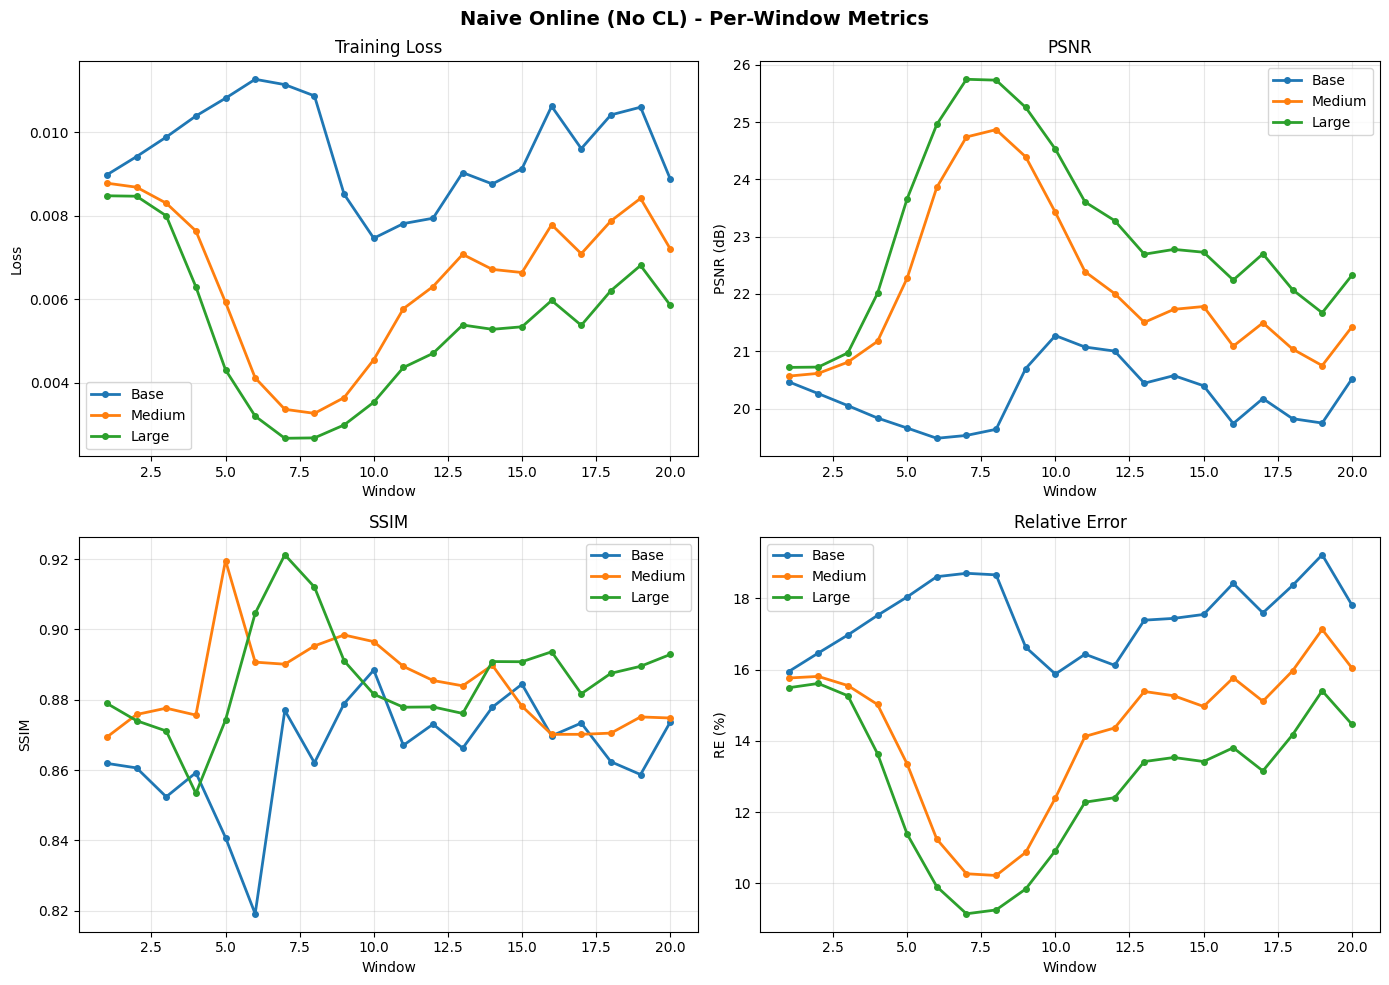

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for mn, col in [('base', 'tab:blue'), ('medium', 'tab:orange'), ('large', 'tab:green')]:
    m = all_metrics[(mn, 'naive')]
    axes[0,0].plot(m['window'], m['loss'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[0,1].plot(m['window'], m['psnr'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[1,0].plot(m['window'], m['ssim'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[1,1].plot(m['window'], m['relative_error'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
for ax in axes.flat: ax.legend(); ax.grid(True, alpha=0.3)
axes[0,0].set(xlabel='Window', ylabel='Loss', title='Training Loss')
axes[0,1].set(xlabel='Window', ylabel='PSNR (dB)', title='PSNR')
axes[1,0].set(xlabel='Window', ylabel='SSIM', title='SSIM')
axes[1,1].set(xlabel='Window', ylabel='RE (%)', title='Relative Error')
plt.suptitle('Naive Online (No CL) - Per-Window Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results/naive_curves.png', dpi=300, bbox_inches='tight')
plt.show()


Best model for Naive Online (No CL): base (PSNR: 14.90 dB)


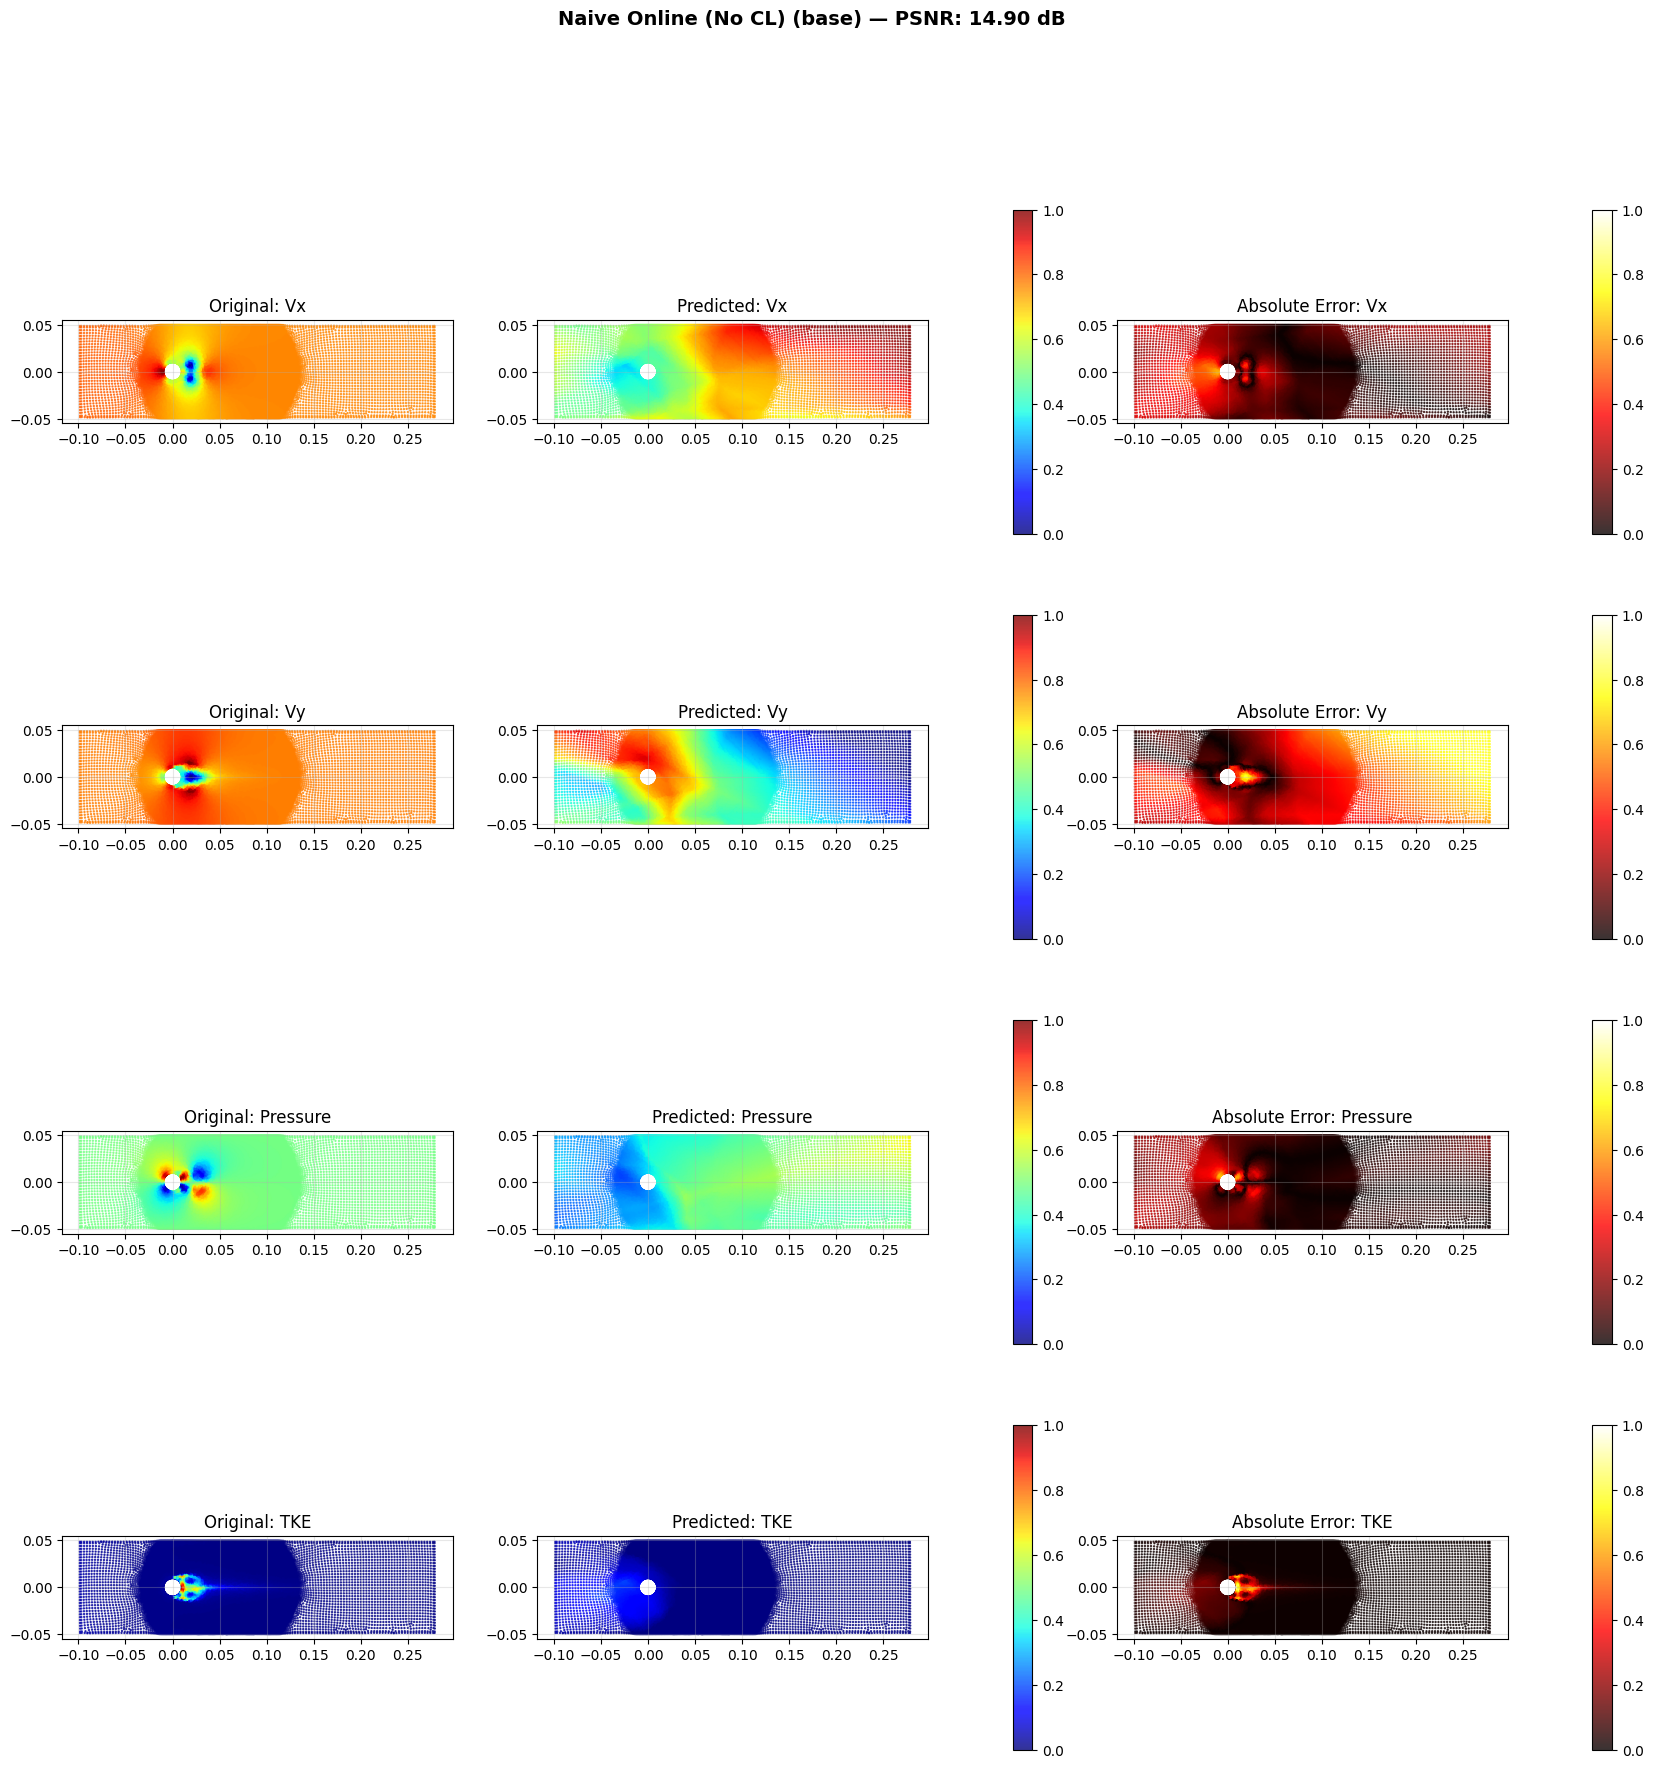

  Timestep: 0.0000 (index 0/300), Points: 26,397, Z-planes: 1


In [16]:
# Naive Online (No CL) — Flow Field Visualization
best_model_name = max(
    ['base', 'medium', 'large'],
    key=lambda m: all_evals[(m, 'naive')]['psnr_db']
)
best_psnr = all_evals[(best_model_name, 'naive')]['psnr_db']
best_model = MODELS[best_model_name]().to(device)
best_model.load_state_dict(torch.load(
    f'/kaggle/working/results/naive_{best_model_name}/{best_model_name}_final.pth',
    map_location=device))
print(f'Best model for Naive Online (No CL): {best_model_name} (PSNR: {best_psnr:.2f} dB)')
visualize_flow_field(
    best_model, dataset, device, timestep_idx=0,
    title=f'Naive Online (No CL) ({best_model_name}) — PSNR: {best_psnr:.2f} dB',
    save_path=f'/kaggle/working/results/naive_flow_field.png'
)


---
## 2. ER Scaled

In [17]:
for model_name, ModelClass in MODELS.items():
    out_dir = "/kaggle/working/results/er_scaled_{}/".format(model_name)
    model = ModelClass().to(device)
    strategy = STRATEGIES['er_scaled']()
    metrics, eval_res, preds = train_online_cl(
        model=model, dataset=dataset, device=device,
        epochs_per_window=EPOCHS_PER_WINDOW, model_name=model_name,
        output_dir=out_dir, strategy=strategy, num_windows=NUM_WINDOWS)
    all_metrics[(model_name, 'er_scaled')] = metrics
    all_metrics[(model_name, 'er_scaled')] = metrics
    all_evals[(model_name, 'er_scaled')] = eval_res



[Training Configuration]
  Strategy     : er_scaled
  Model        : base (6,692 parameters, 26.1 KB)
  Windows      : 20
  Epochs/window: 100
  Device       : cuda
  Timesteps    : 300 total, 15 per window

  Window   1/20: PSNR=20.49 dB, SSIM=0.8732, RE=15.91%, Time=2.17s
  Window   2/20: PSNR=20.35 dB, SSIM=0.8611, RE=16.29%, Time=4.30s
  Window   3/20: PSNR=20.32 dB, SSIM=0.8552, RE=16.45%, Time=2.60s
  Window   4/20: PSNR=20.30 dB, SSIM=0.8376, RE=16.61%, Time=2.48s
  Window   5/20: PSNR=20.86 dB, SSIM=0.8525, RE=15.71%, Time=2.44s
  Window   6/20: PSNR=22.41 dB, SSIM=0.8539, RE=13.29%, Time=2.46s
  Window   7/20: PSNR=23.63 dB, SSIM=0.8834, RE=11.67%, Time=2.44s
  Window   8/20: PSNR=23.95 dB, SSIM=0.8883, RE=11.36%, Time=2.43s
  Window   9/20: PSNR=23.59 dB, SSIM=0.8994, RE=11.92%, Time=2.44s
  Window  10/20: PSNR=22.60 dB, SSIM=0.8895, RE=13.63%, Time=2.41s
  Window  11/20: PSNR=21.66 dB, SSIM=0.8986, RE=15.36%, Time=2.43s
  Window  12/20: PSNR=21.28 dB, SSIM=0.8859, RE=15.62%

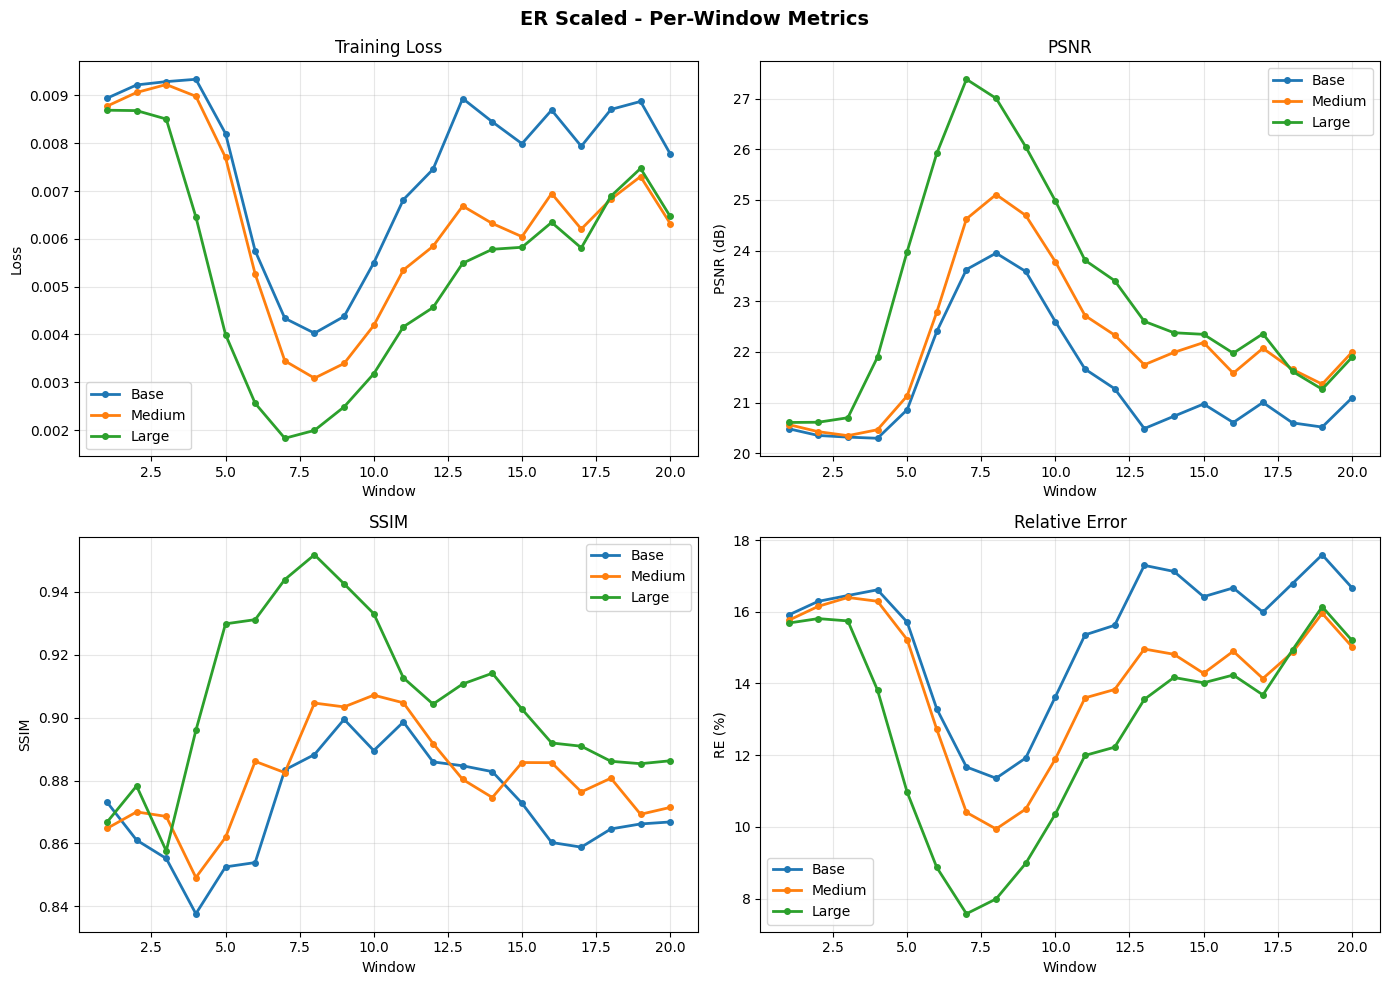

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for mn, col in [('base', 'tab:blue'), ('medium', 'tab:orange'), ('large', 'tab:green')]:
    m = all_metrics[(mn, 'er_scaled')]
    axes[0,0].plot(m['window'], m['loss'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[0,1].plot(m['window'], m['psnr'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[1,0].plot(m['window'], m['ssim'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[1,1].plot(m['window'], m['relative_error'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
for ax in axes.flat: ax.legend(); ax.grid(True, alpha=0.3)
axes[0,0].set(xlabel='Window', ylabel='Loss', title='Training Loss')
axes[0,1].set(xlabel='Window', ylabel='PSNR (dB)', title='PSNR')
axes[1,0].set(xlabel='Window', ylabel='SSIM', title='SSIM')
axes[1,1].set(xlabel='Window', ylabel='RE (%)', title='Relative Error')
plt.suptitle('ER Scaled - Per-Window Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results/er_scaled_curves.png', dpi=300, bbox_inches='tight')
plt.show()


Best model for ER Scaled: large (PSNR: 22.03 dB)


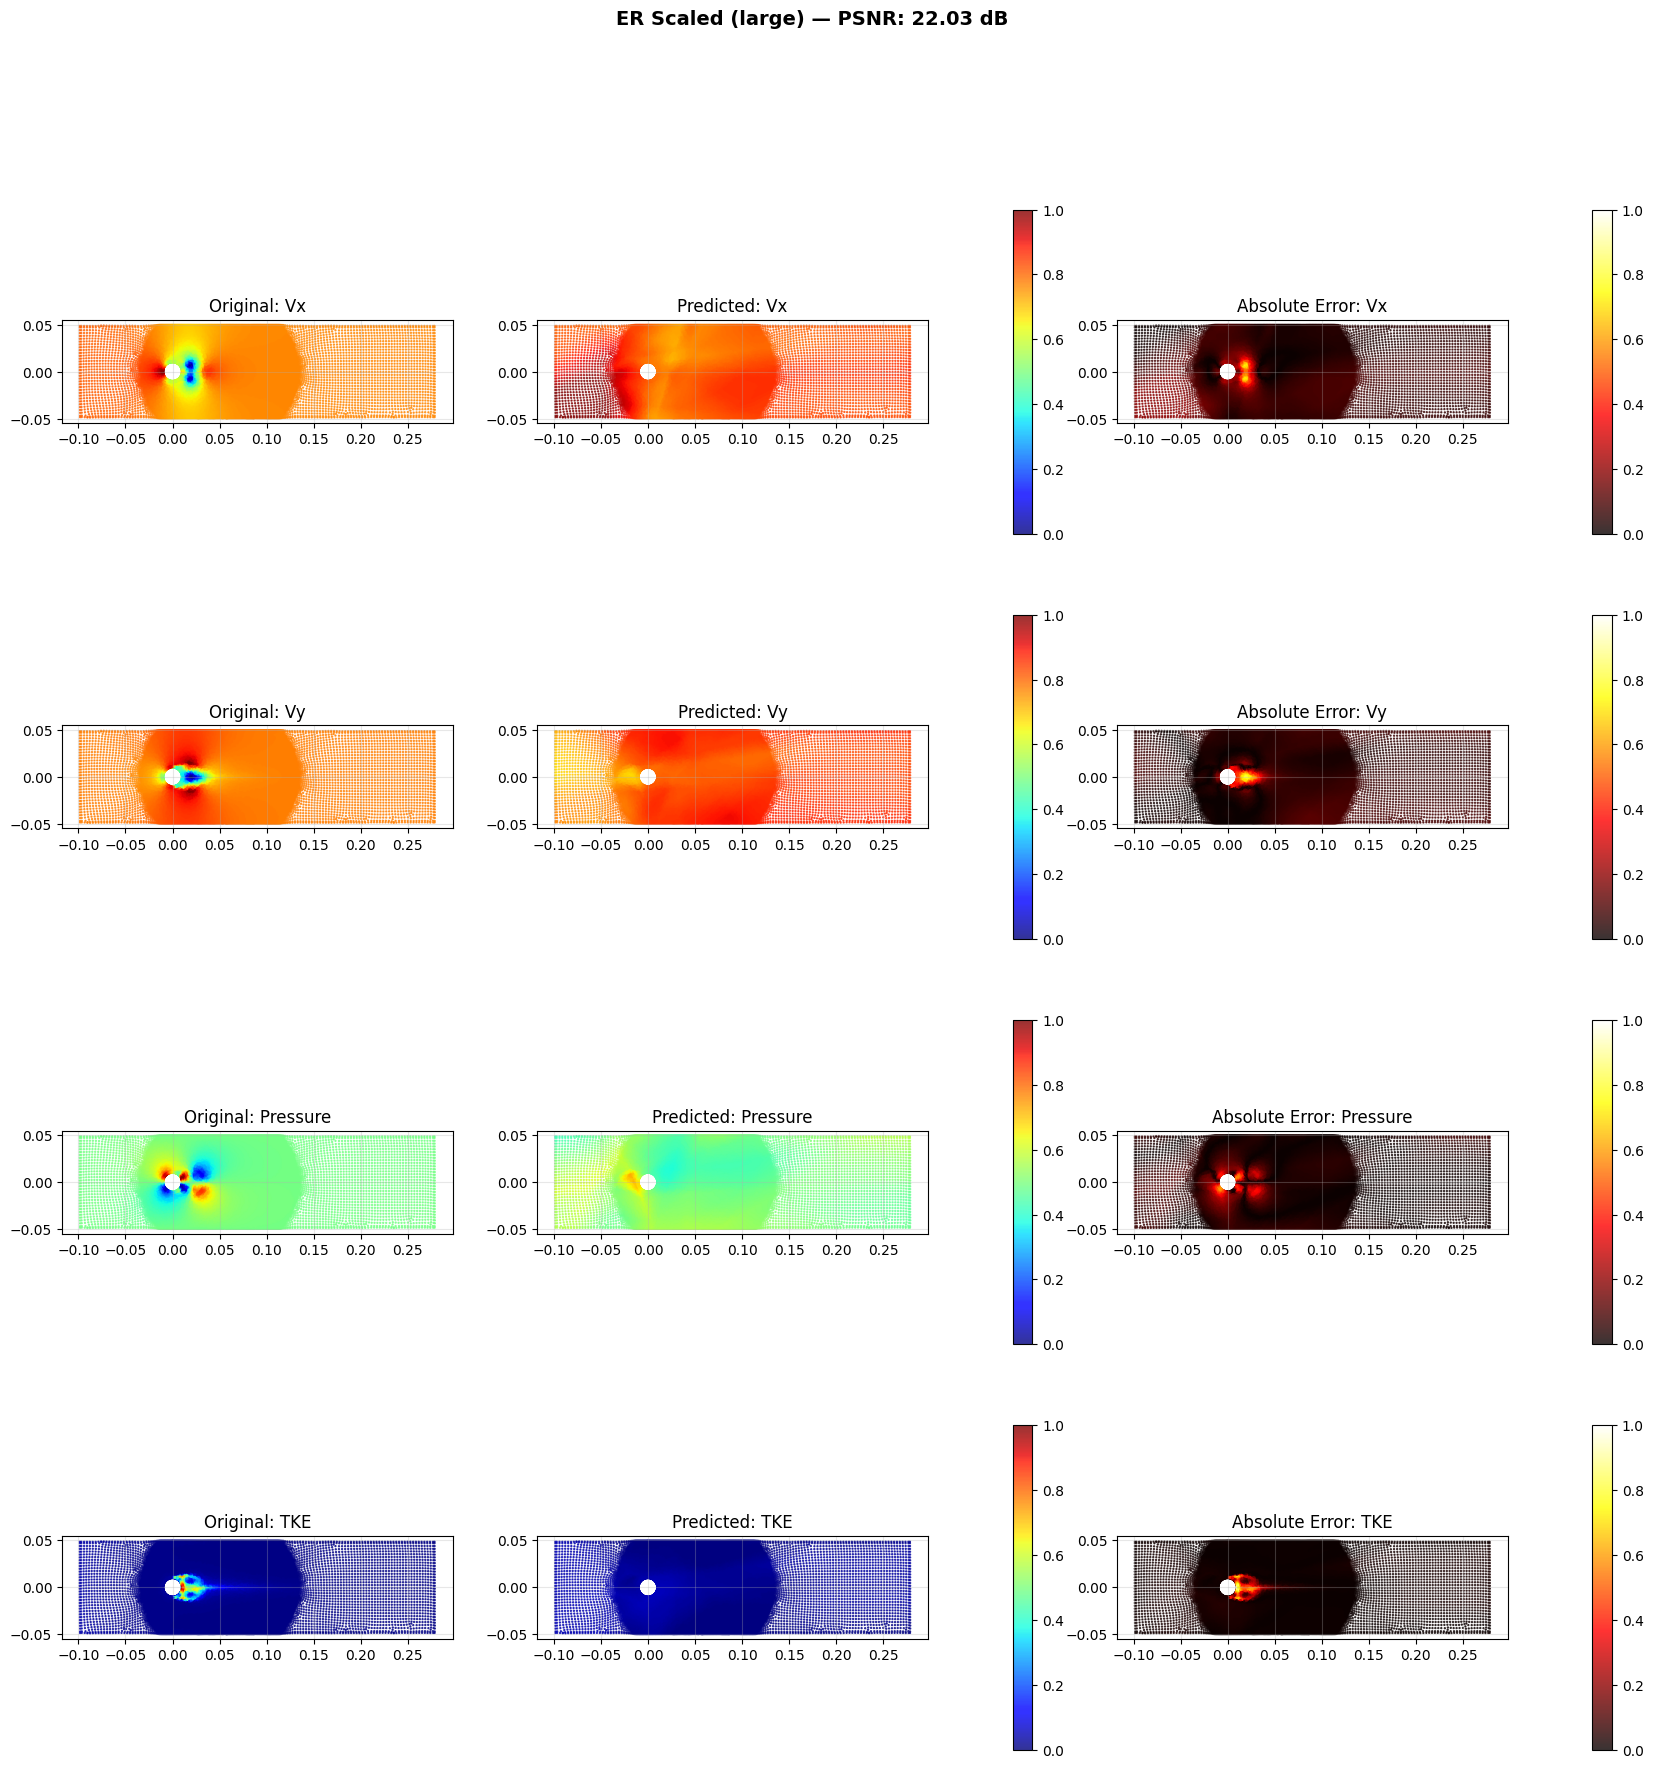

  Timestep: 0.0000 (index 0/300), Points: 26,397, Z-planes: 1


In [19]:
# ER Scaled — Flow Field Visualization
best_model_name = max(
    ['base', 'medium', 'large'],
    key=lambda m: all_evals[(m, 'er_scaled')]['psnr_db']
)
best_psnr = all_evals[(best_model_name, 'er_scaled')]['psnr_db']
best_model = MODELS[best_model_name]().to(device)
best_model.load_state_dict(torch.load(
    f'/kaggle/working/results/er_scaled_{best_model_name}/{best_model_name}_final.pth',
    map_location=device))
print(f'Best model for ER Scaled: {best_model_name} (PSNR: {best_psnr:.2f} dB)')
visualize_flow_field(
    best_model, dataset, device, timestep_idx=0,
    title=f'ER Scaled ({best_model_name}) — PSNR: {best_psnr:.2f} dB',
    save_path=f'/kaggle/working/results/er_scaled_flow_field.png'
)


---
## 3. ER Aggressive

In [20]:
for model_name, ModelClass in MODELS.items():
    out_dir = "/kaggle/working/results/er_aggressive_{}/".format(model_name)
    model = ModelClass().to(device)
    strategy = STRATEGIES['er_aggressive']()
    metrics, eval_res, preds = train_online_cl(
        model=model, dataset=dataset, device=device,
        epochs_per_window=EPOCHS_PER_WINDOW, model_name=model_name,
        output_dir=out_dir, strategy=strategy, num_windows=NUM_WINDOWS)
    all_metrics[(model_name, 'er_aggressive')] = metrics
    all_metrics[(model_name, 'er_aggressive')] = metrics
    all_evals[(model_name, 'er_aggressive')] = eval_res



[Training Configuration]
  Strategy     : er_aggressive
  Model        : base (6,692 parameters, 26.1 KB)
  Windows      : 20
  Epochs/window: 100
  Device       : cuda
  Timesteps    : 300 total, 15 per window

  Window   1/20: PSNR=20.12 dB, SSIM=0.8824, RE=16.59%, Time=2.13s
  Window   2/20: PSNR=20.37 dB, SSIM=0.8605, RE=16.26%, Time=10.23s
  Window   3/20: PSNR=20.37 dB, SSIM=0.8568, RE=16.37%, Time=2.98s
  Window   4/20: PSNR=20.54 dB, SSIM=0.8721, RE=16.15%, Time=2.81s
  Window   5/20: PSNR=20.92 dB, SSIM=0.8865, RE=15.61%, Time=2.67s
  Window   6/20: PSNR=21.66 dB, SSIM=0.8781, RE=14.48%, Time=2.65s
  Window   7/20: PSNR=22.83 dB, SSIM=0.8754, RE=12.79%, Time=2.61s
  Window   8/20: PSNR=23.38 dB, SSIM=0.8853, RE=12.13%, Time=2.63s
  Window   9/20: PSNR=23.28 dB, SSIM=0.8964, RE=12.36%, Time=2.56s
  Window  10/20: PSNR=22.62 dB, SSIM=0.9047, RE=13.60%, Time=2.59s
  Window  11/20: PSNR=21.74 dB, SSIM=0.8998, RE=15.22%, Time=2.61s
  Window  12/20: PSNR=21.25 dB, SSIM=0.8941, RE=1

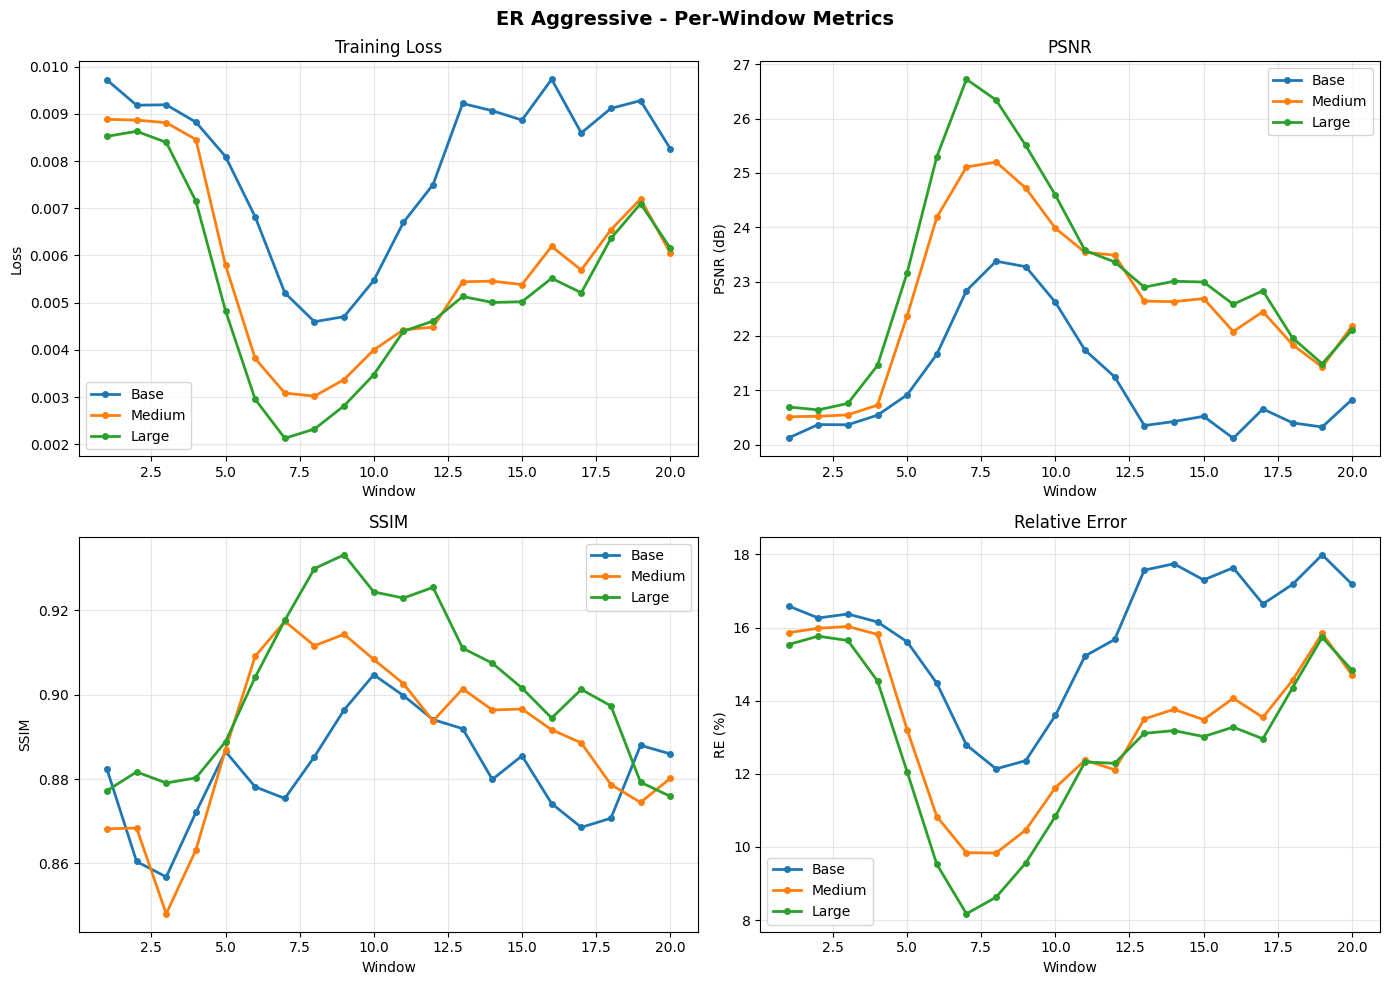

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for mn, col in [('base', 'tab:blue'), ('medium', 'tab:orange'), ('large', 'tab:green')]:
    m = all_metrics[(mn, 'er_aggressive')]
    axes[0,0].plot(m['window'], m['loss'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[0,1].plot(m['window'], m['psnr'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[1,0].plot(m['window'], m['ssim'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
    axes[1,1].plot(m['window'], m['relative_error'], '-o', color=col, lw=2, ms=4, label=mn.capitalize())
for ax in axes.flat: ax.legend(); ax.grid(True, alpha=0.3)
axes[0,0].set(xlabel='Window', ylabel='Loss', title='Training Loss')
axes[0,1].set(xlabel='Window', ylabel='PSNR (dB)', title='PSNR')
axes[1,0].set(xlabel='Window', ylabel='SSIM', title='SSIM')
axes[1,1].set(xlabel='Window', ylabel='RE (%)', title='Relative Error')
plt.suptitle('ER Aggressive - Per-Window Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results/er_aggressive_curves.png', dpi=300, bbox_inches='tight')
plt.show()


Best model for ER Aggressive: medium (PSNR: 23.27 dB)


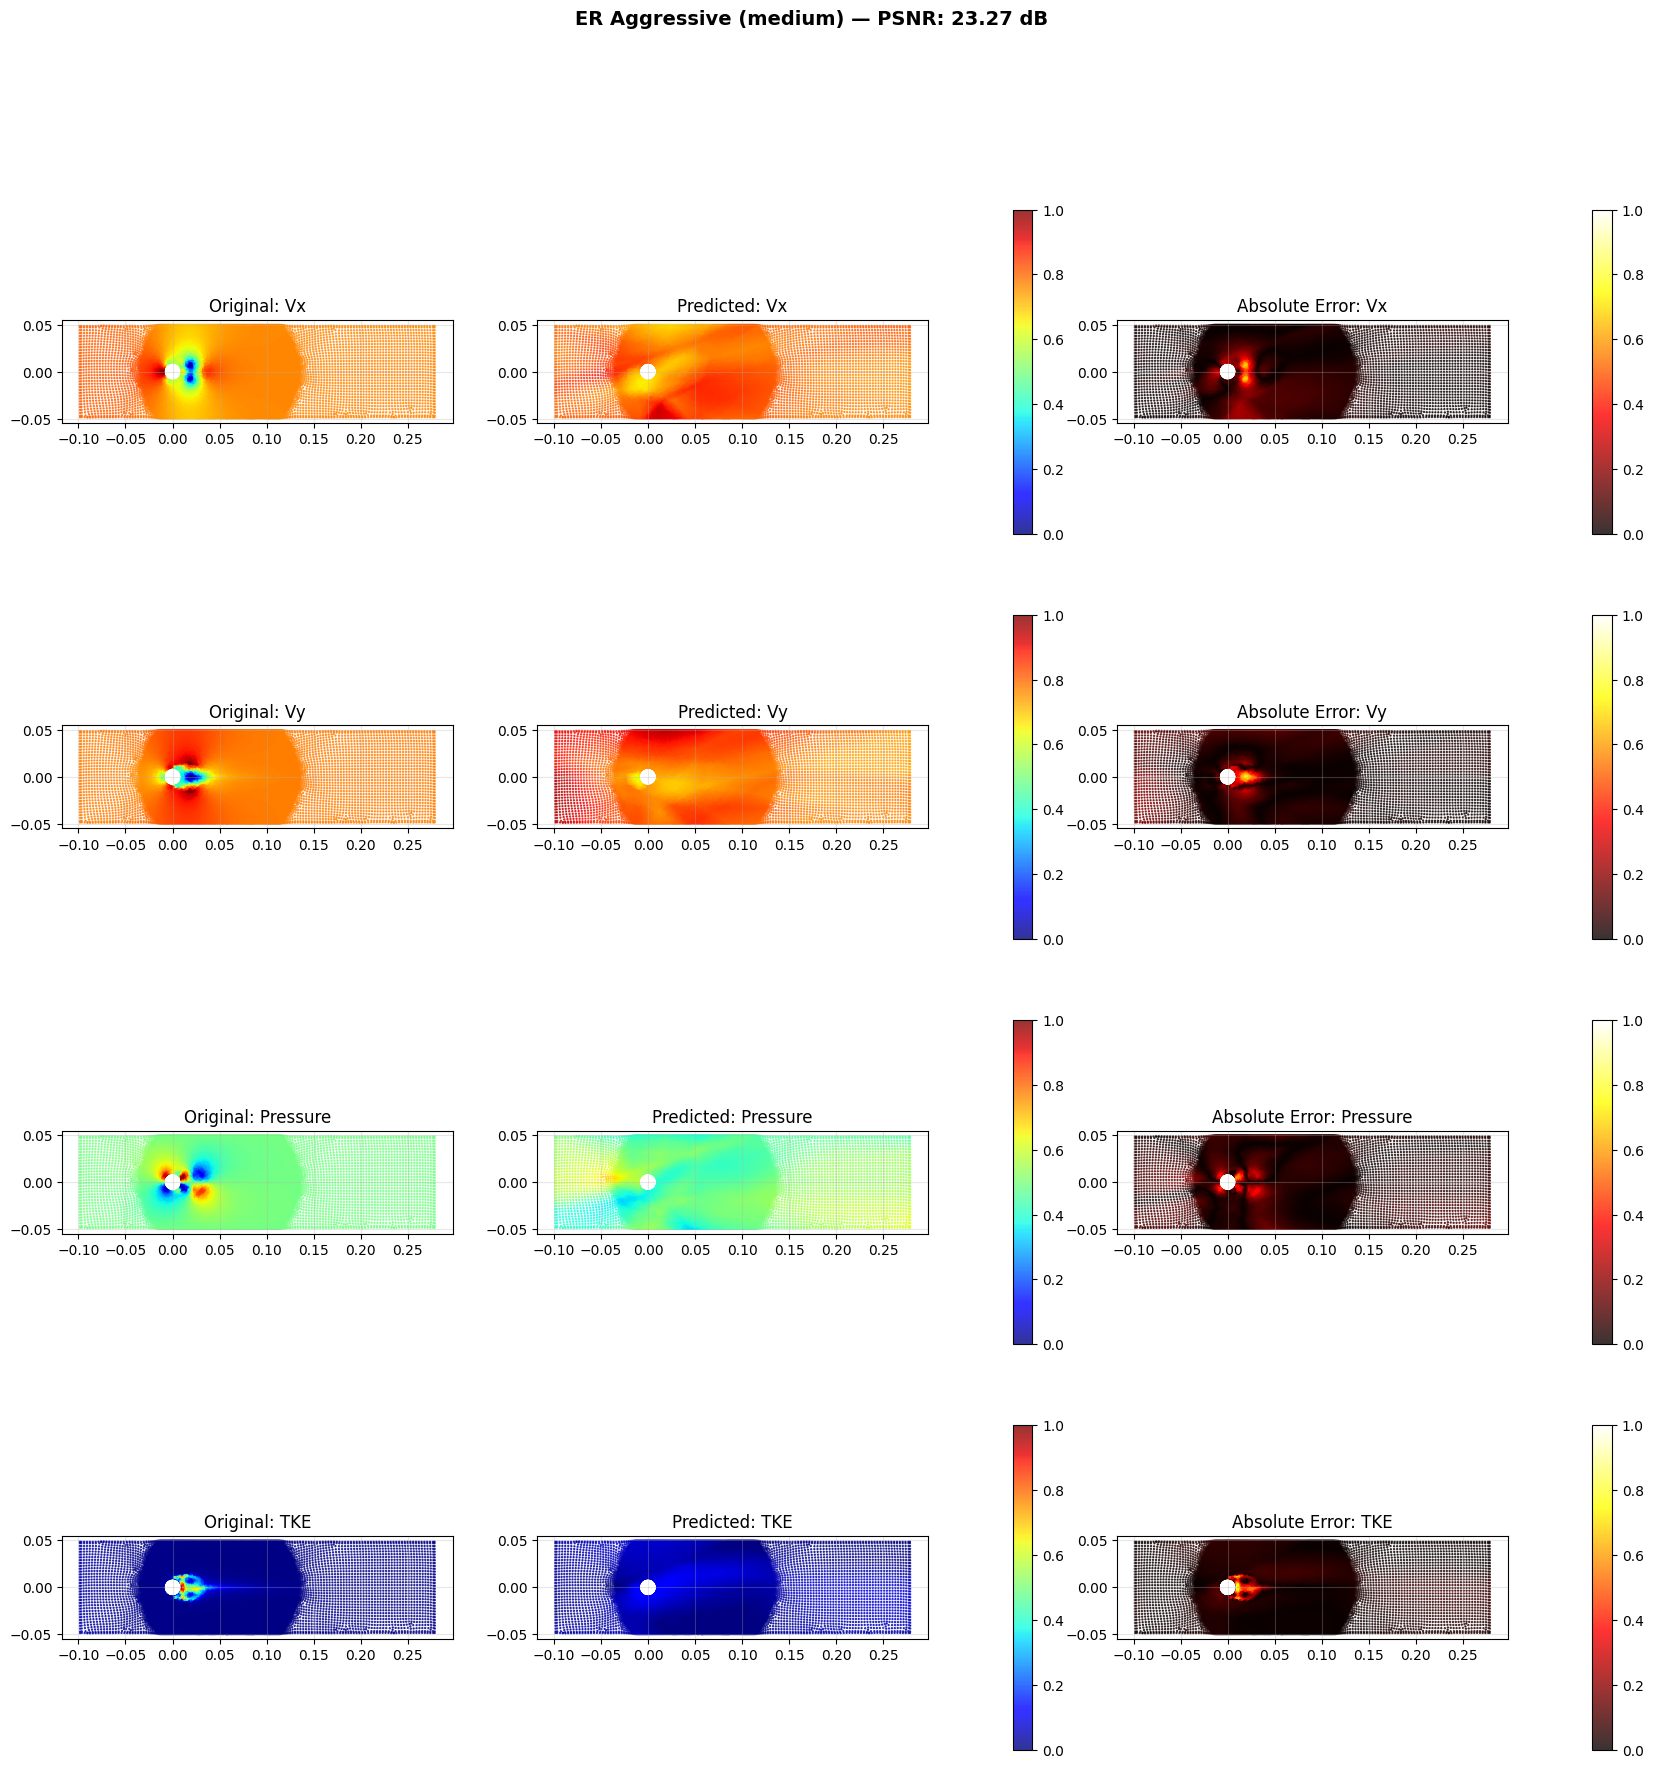

  Timestep: 0.0000 (index 0/300), Points: 26,397, Z-planes: 1


In [22]:
# ER Aggressive — Flow Field Visualization
best_model_name = max(
    ['base', 'medium', 'large'],
    key=lambda m: all_evals[(m, 'er_aggressive')]['psnr_db']
)
best_psnr = all_evals[(best_model_name, 'er_aggressive')]['psnr_db']
best_model = MODELS[best_model_name]().to(device)
best_model.load_state_dict(torch.load(
    f'/kaggle/working/results/er_aggressive_{best_model_name}/{best_model_name}_final.pth',
    map_location=device))
print(f'Best model for ER Aggressive: {best_model_name} (PSNR: {best_psnr:.2f} dB)')
visualize_flow_field(
    best_model, dataset, device, timestep_idx=0,
    title=f'ER Aggressive ({best_model_name}) — PSNR: {best_psnr:.2f} dB',
    save_path=f'/kaggle/working/results/er_aggressive_flow_field.png'
)


---
## 4. Cross-Strategy Comparison

In [23]:
COMP_DIR = "/kaggle/working/results/comparison_cl"
os.makedirs(COMP_DIR, exist_ok=True)
REF = {'base': {'psnr': 32.15, 'ssim': 0.9550, 're': 4.41},
       'medium': {'psnr': 33.58, 'ssim': 0.9583, 're': 3.74},
       'large': {'psnr': 35.99, 'ssim': 0.9856, 're': 2.83}}

print("=" * 90)
print("  FULL-DATASET EVALUATION")
print("=" * 90)
print("{:<12s} {:<16s} {:>10s} {:>10s} {:>10s} {:>10s}".format("Model", "Strategy", "PSNR", "SSIM", "RE(%)", "Time(s)"))
print("-" * 90)
for mn in ['base', 'medium', 'large']:
    r = REF[mn]
    print("{:<12s} {:<16s} {:>10.2f} {:>10.4f} {:>10.2f} {:>10s}".format(mn, "Offline(ref)", r["psnr"], r["ssim"], r["re"], "-"))
    for sn in ['naive', 'er_scaled', 'er_aggressive']:
        if (mn, sn) in all_evals:
            ev = all_evals[(mn, sn)]
            print("{:<12s} {:<16s} {:>10.2f} {:>10.4f} {:>10.2f} {:>10.1f}".format(mn, sn, ev["psnr_db"], ev["ssim"], ev["relative_error_pct"], ev["training_time_s"]))
    print("")
print("=" * 90)


  FULL-DATASET EVALUATION
Model        Strategy               PSNR       SSIM      RE(%)    Time(s)
------------------------------------------------------------------------------------------
base         Offline(ref)          32.15     0.9550       4.41          -
base         naive                 14.90     0.7996      32.07       42.7
base         er_scaled             21.47     0.8830      15.07       49.9
base         er_aggressive         21.60     0.8958      14.86       59.4

medium       Offline(ref)          33.58     0.9583       3.74          -
medium       naive                 13.38     0.7822      38.21       71.6
medium       er_scaled             21.98     0.8782      14.22       77.4
medium       er_aggressive         23.27     0.8961      12.26       88.2

large        Offline(ref)          35.99     0.9856       2.83          -
large        naive                 13.18     0.7941      39.07       85.3
large        er_scaled             22.03     0.9034      14.14     

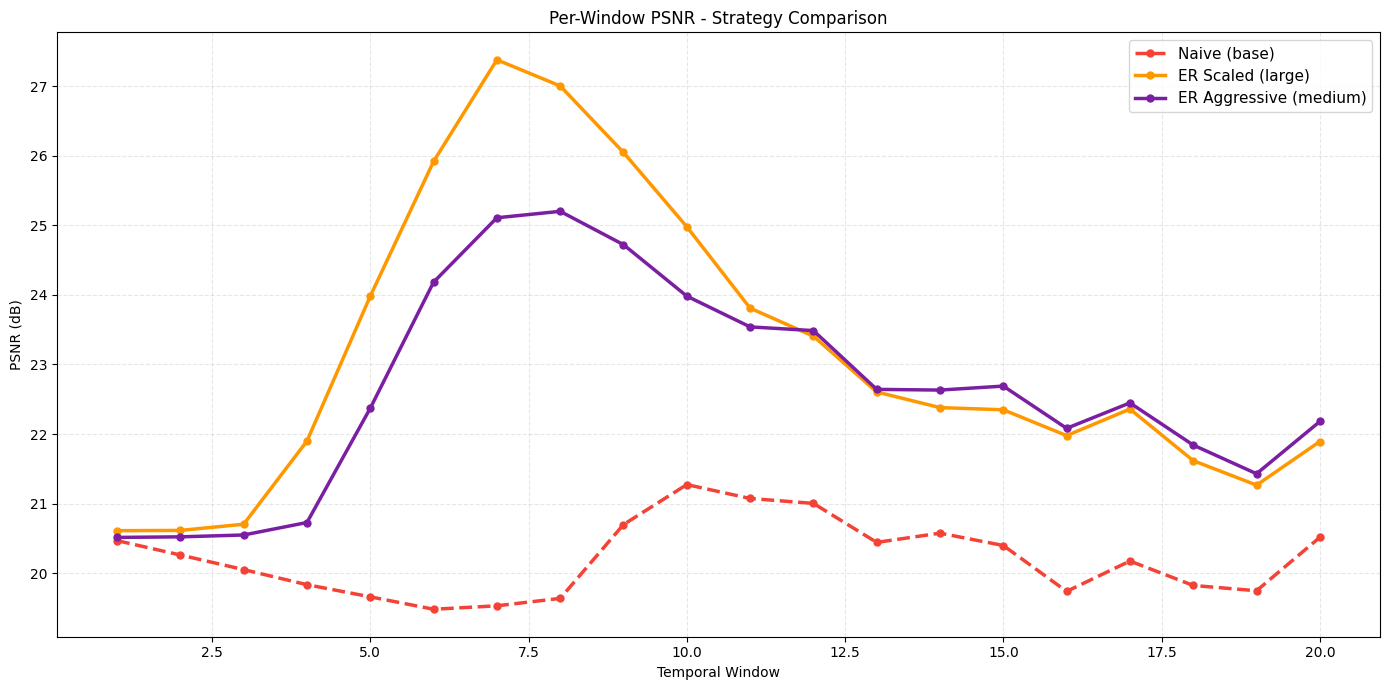

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))
sm = {'naive': ('Naive', '#F44336', '--'), 'er_scaled': ('ER Scaled', '#FF9800', '-'), 'er_aggressive': ('ER Aggressive', '#7B1FA2', '-')}
for sn, (lb, co, ls) in sm.items():
    bm = max(['base', 'medium', 'large'], key=lambda m: all_evals[(m, sn)]['psnr_db'])
    m = all_metrics[(bm, sn)]
    ax.plot(m['window'], m['psnr'], ls, color=co, lw=2.5, marker='o', ms=5, label='{} ({})'.format(lb, bm))
ax.set(xlabel='Temporal Window', ylabel='PSNR (dB)', title='Per-Window PSNR - Strategy Comparison')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout(); plt.savefig(os.path.join(COMP_DIR, 'cl_psnr_per_window.png'), dpi=300, bbox_inches='tight'); plt.show()


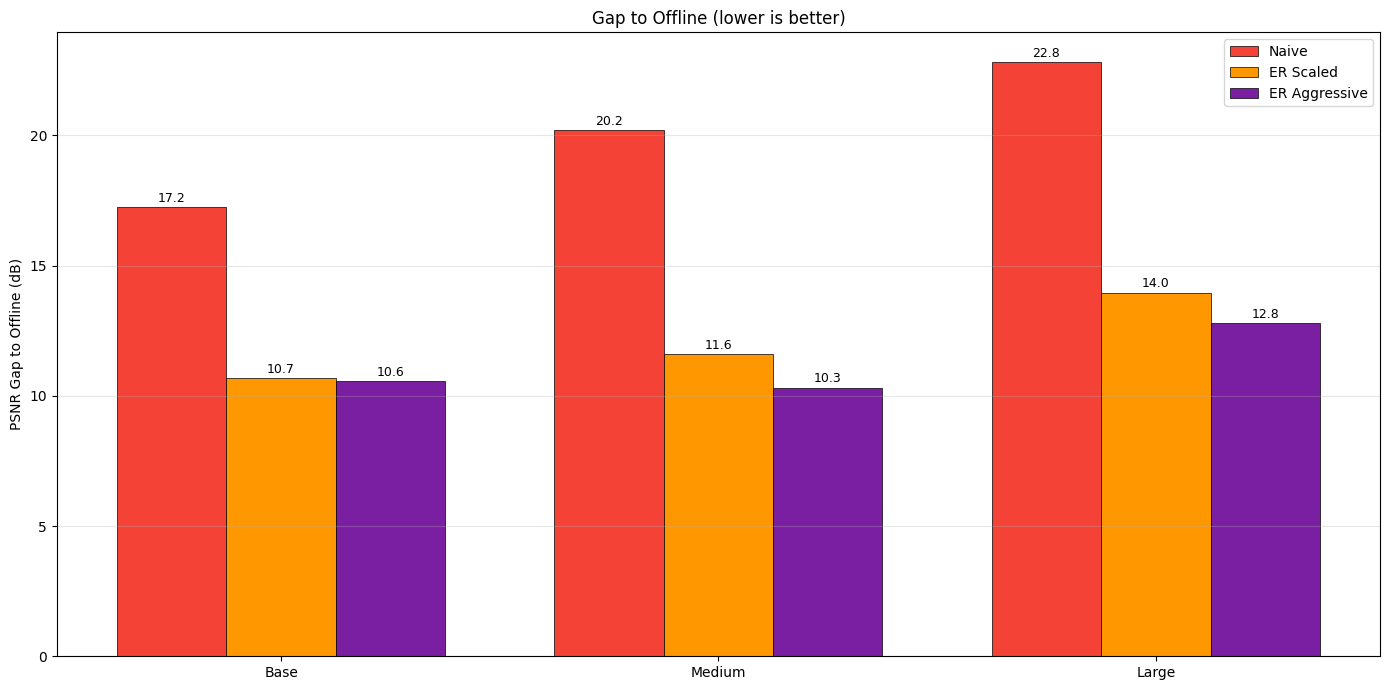

In [27]:
fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(3); width = 0.25
for i, (sn, (lb, co, _)) in enumerate(sm.items()):
    gaps = [REF[mn]['psnr'] - all_evals[(mn, sn)]['psnr_db'] for mn in ['base', 'medium', 'large']]
    bars = ax.bar(x_pos + i*width, gaps, width, label=lb, color=co, edgecolor='black', lw=0.5)
    for b, v in zip(bars, gaps): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, '{:.1f}'.format(v), ha='center', fontsize=9)
ax.set_xticks(x_pos + width); ax.set_xticklabels(['Base', 'Medium', 'Large'])
ax.set(ylabel='PSNR Gap to Offline (dB)', title='Gap to Offline (lower is better)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(os.path.join(COMP_DIR, 'cl_gap_to_offline.png'), dpi=300, bbox_inches='tight'); plt.show()


---
## 5. Save and Download

In [28]:
combined = {}
for (mn, sn), ev in all_evals.items():
    combined["{}_{}".format(mn, sn)] = ev
with open(os.path.join(COMP_DIR, 'cl_all_results.json'), 'w') as f:
    json.dump(combined, f, indent=2)
print("Results saved. {} experiments.".format(len(combined)))

import shutil
zip_path = shutil.make_archive('/kaggle/working/cl_results', 'zip', '/kaggle/working/results')
print("Archive: {} ({:.1f} MB)".format(zip_path, os.path.getsize(zip_path)/(1024*1024)))


Results saved. 9 experiments.
Archive: /kaggle/working/cl_results.zip (8.3 MB)
